[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Boyu-Zhang-UOI/pml-f2026-notebooks/blob/main/03-classical-ml/07_boosting_synthesis.ipynb)

# Four Families, One Split

**Session 14 · no homework grades this · the project starts here**

The end of the classical module, and the only fair way to close it: every model
on the same split, judged by the same metric, given the same tuning budget, with
the test set opened once at the very end.

The comparison is the deliverable. Which family wins on this dataset matters
much less than being able to say *why* it won and what it cost.

In [1]:
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import sklearn
import xgboost
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split

print("scikit-learn", sklearn.__version__)
print("xgboost     ", xgboost.__version__)

X, y = make_classification(n_samples=12000, n_features=25, n_informative=10,
                           n_redundant=5, class_sep=0.9, flip_y=0.03,
                           random_state=14)

X_rest, X_test, y_rest, y_test = train_test_split(
    X, y, test_size=0.2, random_state=0, stratify=y)
X_train, X_valid, y_train, y_valid = train_test_split(
    X_rest, y_rest, test_size=0.2, random_state=0, stratify=y_rest)

print(f"\ntrain {X_train.shape}   validation {X_valid.shape}   test {X_test.shape}")
print(f"positive rate {y.mean():.3f}")

scikit-learn 1.7.2
xgboost      3.4.1

train (7680, 25)   validation (1920, 25)   test (2400, 25)
positive rate 0.499


## The rules of the comparison

- one split, fixed above;
- one metric, ROC-AUC, chosen because the classes are balanced and we care about
  ranking;
- one budget, twenty candidates per model in a randomised search;
- selection on cross-validated training folds only;
- wall-clock time recorded, because a model that takes an hour is a different
  proposition from one that takes a second.

## Round 1: four families, same budget

In [2]:
from scipy.stats import loguniform, randint
from sklearn.ensemble import HistGradientBoostingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import RandomizedSearchCV
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier

BUDGET, FOLDS = 20, 4

contenders = {
    "logistic regression": (
        make_pipeline(StandardScaler(), LogisticRegression(max_iter=3000)),
        {"logisticregression__C": loguniform(1e-3, 1e3)}),
    "random forest": (
        RandomForestClassifier(random_state=0, n_jobs=-1),
        {"n_estimators": randint(100, 400), "max_depth": randint(3, 20),
         "max_features": ["sqrt", "log2", 0.5], "min_samples_leaf": randint(1, 20)}),
    "hist gradient boosting": (
        HistGradientBoostingClassifier(random_state=0),
        {"learning_rate": loguniform(1e-2, 5e-1), "max_iter": randint(60, 400),
         "max_leaf_nodes": randint(10, 60), "l2_regularization": loguniform(1e-3, 1e1)}),
    "xgboost": (
        XGBClassifier(random_state=0, n_jobs=-1, eval_metric="logloss",
                      tree_method="hist"),
        {"learning_rate": loguniform(1e-2, 5e-1), "n_estimators": randint(60, 400),
         "max_depth": randint(2, 10), "subsample": [0.6, 0.8, 1.0],
         "colsample_bytree": [0.6, 0.8, 1.0]}),
}

rows, fitted = [], {}
for name, (estimator, space) in contenders.items():
    t0 = time.perf_counter()
    search = RandomizedSearchCV(estimator, space, n_iter=BUDGET, cv=FOLDS,
                                scoring="roc_auc", random_state=0,
                                n_jobs=-1).fit(X_train, y_train)
    seconds = time.perf_counter() - t0
    fitted[name] = search.best_estimator_
    rows.append({
        "model": name,
        "cv roc_auc": round(search.best_score_, 4),
        "validation roc_auc": round(
            sklearn.metrics.roc_auc_score(
                y_valid, search.best_estimator_.predict_proba(X_valid)[:, 1]), 4),
        "search seconds": round(seconds, 1),
    })
    print(f"  {name:<24} done in {seconds:>6.1f}s")

comparison = pd.DataFrame(rows).set_index("model")
print()
print(comparison.to_string())

  logistic regression      done in    1.8s


  random forest            done in   23.1s


  hist gradient boosting   done in   16.4s


  xgboost                  done in    3.9s

                        cv roc_auc  validation roc_auc  search seconds
model                                                                 
logistic regression         0.8273              0.8406             1.8
random forest               0.9747              0.9721            23.1
hist gradient boosting      0.9794              0.9769            16.4
xgboost                     0.9793              0.9767             3.9


Read the two score columns together. The cross-validated number is what the
search optimised, so it is the one that is slightly optimistic; the validation
number is a fresh split and is the better estimate of the two. If they disagree
by much, the search has fitted the folds.

Read the time column next to them. On this data the boosted models are the ones
worth the wait; on a smaller table, or one with a strong linear structure, the
logistic regression would be the sensible answer and would have finished before
you looked up.

## Round 2: what learning rate actually buys

Boosting fits each new tree to what the previous trees got wrong, and the
learning rate is how much of that correction it accepts. Small rate plus many
trees is the classic recipe — and the product of the two is roughly constant for
a given amount of fitting.

In [3]:
from sklearn.metrics import roc_auc_score

grid_rows = []
for lr in (0.02, 0.05, 0.1, 0.3):
    for n_trees in (50, 100, 200, 400):
        t0 = time.perf_counter()
        model = HistGradientBoostingClassifier(
            learning_rate=lr, max_iter=n_trees, early_stopping=False,
            random_state=0).fit(X_train, y_train)
        grid_rows.append({
            "learning_rate": lr, "trees": n_trees,
            "train": round(roc_auc_score(y_train, model.predict_proba(X_train)[:, 1]), 4),
            "validation": round(roc_auc_score(y_valid, model.predict_proba(X_valid)[:, 1]), 4),
            "seconds": round(time.perf_counter() - t0, 2),
        })

grid = pd.DataFrame(grid_rows)
print(grid.pivot(index="learning_rate", columns="trees", values="validation").to_string())
print("\n(validation ROC-AUC; rows are learning rates, columns are tree counts)")

trees             50      100     200     400
learning_rate                                
0.02           0.9473  0.9620  0.9715  0.9748
0.05           0.9652  0.9727  0.9745  0.9756
0.10           0.9737  0.9750  0.9760  0.9765
0.30           0.9725  0.9744  0.9755  0.9761

(validation ROC-AUC; rows are learning rates, columns are tree counts)


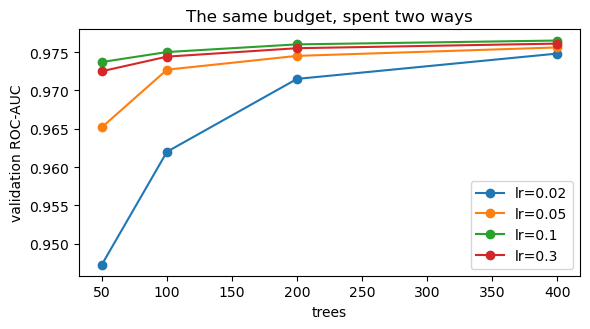

In [4]:
fig, ax = plt.subplots(figsize=(6, 3.4))
for lr, part in grid.groupby("learning_rate"):
    ax.plot(part.trees, part.validation, "o-", label=f"lr={lr}")
ax.set_xlabel("trees"); ax.set_ylabel("validation ROC-AUC")
ax.set_title("The same budget, spent two ways"); ax.legend()
plt.tight_layout(); plt.show()

The diagonal is the point: a small learning rate with many trees and a large
learning rate with few trees land in similar places, and the small-rate version
is usually a little better and a lot slower. That is the trade you are making
whenever you touch either knob — they are not independent settings.

## Round 3: early stopping, on the right data

Rather than guessing the tree count, let the model add trees until a *validation*
score stops improving. The rule that matters: the set used to stop is not the set
used to report.

asked for 2000 trees, stopped at 402 after 0.9s
best validation AUC during training: 0.9755


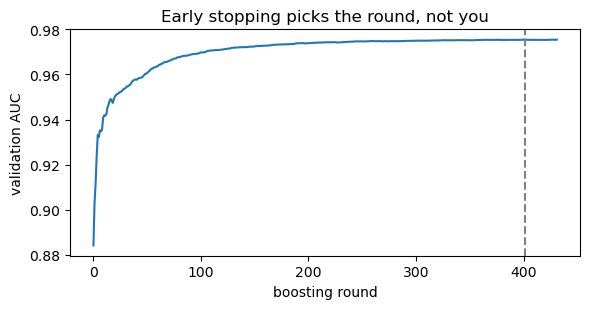

In [5]:
stopped = XGBClassifier(
    n_estimators=2000, learning_rate=0.05, max_depth=5, subsample=0.8,
    colsample_bytree=0.8, early_stopping_rounds=30, eval_metric="auc",
    tree_method="hist", random_state=0, n_jobs=-1)

t0 = time.perf_counter()
stopped.fit(X_train, y_train, eval_set=[(X_valid, y_valid)], verbose=False)
seconds = time.perf_counter() - t0

print(f"asked for 2000 trees, stopped at {stopped.best_iteration + 1} "
      f"after {seconds:.1f}s")
print(f"best validation AUC during training: {stopped.best_score:.4f}")

history = stopped.evals_result()["validation_0"]["auc"]
plt.figure(figsize=(6, 3.2))
plt.plot(history)
plt.axvline(stopped.best_iteration, ls="--", color="grey")
plt.xlabel("boosting round"); plt.ylabel("validation AUC")
plt.title("Early stopping picks the round, not you")
plt.tight_layout(); plt.show()

The curve rises steeply, flattens, and then wanders. Everything after the dashed
line is compute spent on noise, and thirty rounds of patience is what separates
"it stopped improving" from "it had a bad round".

**The catch:** the validation set has now been used to choose the number of
trees, which makes it part of training. Its AUC is no longer an unbiased
estimate — which is exactly why there is a third split.

## The test set, once

In [6]:
final_rows = []
for name, model in fitted.items():
    final_rows.append({"model": name,
                       "test roc_auc": roc_auc_score(y_test, model.predict_proba(X_test)[:, 1])})
final_rows.append({"model": "xgboost (early stopped)",
                   "test roc_auc": roc_auc_score(y_test, stopped.predict_proba(X_test)[:, 1])})

final = pd.DataFrame(final_rows).set_index("model").round(4)
final["validation roc_auc"] = list(comparison["validation roc_auc"]) + [round(stopped.best_score, 4)]
print(final.to_string())
print("\nThis is the only time the test set appears in this notebook.")

                         test roc_auc  validation roc_auc
model                                                    
logistic regression            0.8312              0.8406
random forest                  0.9754              0.9721
hist gradient boosting         0.9808              0.9769
xgboost                        0.9797              0.9767
xgboost (early stopped)        0.9785              0.9755

This is the only time the test set appears in this notebook.


## The families, and the bets each one makes

| Family | Assumes | Pays off when | Costs |
|---|---|---|---|
| Linear / logistic | the log-odds are roughly additive in the features | few rows, many features, or interpretability is the deliverable | underfits interactions unless you build them |
| KNN / SVM | nearby points share labels | smooth boundaries, moderate dimension | scaling matters; prediction is slow (KNN) or fitting is (SVM) |
| Random forest | many decorrelated greedy trees average out | mixed types, little tuning time, a solid default | large models, weak extrapolation |
| Boosted trees | errors can be fitted, one small step at a time | tabular data with interactions and enough rows | more knobs, needs early stopping and a validation split |

Nothing here says "use gradient boosting". It says: on a tabular problem with
interactions and ten thousand rows, boosted trees are the model to beat, and
beating them with a linear model is a *result* — it means the structure is
simple and you should say so.

## What to take from this

- A comparison is only a comparison if the split, the metric and the budget are
  shared. Record all three.
- Learning rate and tree count trade against each other; neither is meaningful
  alone.
- Early stopping consumes a validation set. If you stopped on it, do not report
  it.
- Wall-clock time is part of the result.
- The test set is opened once, at the end, for every model at the same time.

## Where to go next

- **Reading, Session 14** — boosting's mechanics and the family table in full.
- **Quiz 2** covers Sessions 8-15; this table is the synthesis it draws on.
- **The project** — this notebook is the shape of your model-selection section.